# Connect to BigQuery and Verify Column Names

In [2]:
from google.cloud import bigquery
import pandas as pd

client = bigquery.Client()

query = """
SELECT *
FROM `analytics_art_sales_mart.fact_art_sales`
"""

df = client.query(query).to_dataframe()
df.head()

/home/thoxo/artsales/art-sales-bigquery-dbt/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,sale_id,artist_id,style_id,year_id,price_usd,loaded_at
0,a2b79297-4533-4f43-9a4c-5c6652e9bf11,5,29,<NA>,1595.0,2026-03-18 12:36:47.635206+00:00
1,b3fb3da4-3b51-48c0-bb81-bf85afae17cf,7,7,5,7550.0,2026-03-18 12:36:47.635206+00:00
2,6c396e7b-c617-4abf-b842-89b560ba9304,11,11,8,28500.0,2026-03-18 12:36:47.635206+00:00
3,0a44ba23-58da-484a-8517-d0d8c0ff8381,12,12,<NA>,1895.0,2026-03-18 12:36:47.635206+00:00
4,63cca341-a833-4942-a50c-d6965fe7f653,17,12,10,13500.0,2026-03-18 12:36:47.635206+00:00


# KPI - Total Sales USD

In [12]:
query = """
SELECT SUM(price_usd) AS total_sales
FROM `analytics_art_sales_mart.fact_art_sales`
"""
total_sales = client.query(query).to_dataframe()
total_sales

/home/thoxo/artsales/art-sales-bigquery-dbt/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,total_sales
0,5097620.0


# Sales Trend Over Time 

In [4]:
query = """
SELECT
    d.year,
    SUM(f.price_usd) AS total_sales
FROM `analytics_art_sales_mart.fact_art_sales` f
JOIN `analytics_art_sales_mart.dim_date` d
ON f.year_id = d.year_id
GROUP BY d.year
ORDER BY d.year
"""

sales_trend = client.query(query).to_dataframe()
sales_trend

/home/thoxo/artsales/art-sales-bigquery-dbt/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,year,total_sales
0,1877,12000.0
1,1892,19200.0
2,1894,3000.0
3,1896,5000.0
4,1920,12000.0
...,...,...
84,2018,210000.0
85,2019,224000.0
86,2020,64125.0
87,2021,170000.0


# Plot Trend

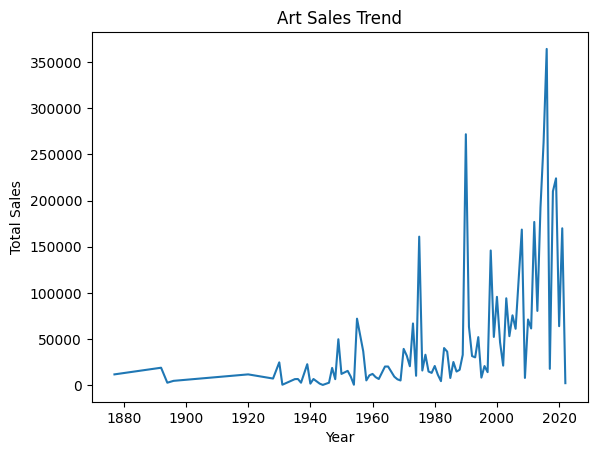

In [5]:
import matplotlib.pyplot as plt

plt.plot(sales_trend['year'], sales_trend['total_sales'])
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.title("Art Sales Trend")
plt.show()

# Top Artists by Revenue

In [8]:
query = """
SELECT
    a.artist_name,
    SUM(f.price_usd) AS total_revenue
FROM `analytics_art_sales_mart.fact_art_sales` f
JOIN `analytics_art_sales_mart.dim_artist` a
ON f.artist_id = a.artist_id
GROUP BY a.artist_name
ORDER BY total_revenue DESC
LIMIT 10
"""
top_artists = client.query(query).to_dataframe()
top_artists

/home/thoxo/artsales/art-sales-bigquery-dbt/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,artist_name,total_revenue
0,russell young,232600.0
1,john baldessari,195000.0
2,alex katz,187000.0
3,ed ruscha,154500.0
4,cindy sherman,141000.0
5,vija celmins,135000.0
6,frank schroeder,120000.0
7,biff elrod,97000.0
8,gustave blache iii,93000.0
9,jasper johns,75000.0


# Sales By Art Style

In [10]:
query = """
SELECT
    s.style_name,
    SUM(f.price_usd) AS total_sales
FROM `analytics_art_sales_mart.fact_art_sales` f
JOIN `analytics_art_sales_mart.dim_style` s
ON f.style_id = s.style_id
GROUP BY s.style_name
ORDER BY total_sales DESC
"""
sales_by_style = client.query(query).to_dataframe()
sales_by_style

/home/thoxo/artsales/art-sales-bigquery-dbt/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,style_name,total_sales
0,pop art,1121750.0
1,realism,995180.0
2,conceptual,746800.0
3,abstract,658495.0
4,expressionism,315630.0
5,abstract expressionism,291135.0
6,photorealism,163500.0
7,minimalism,116230.0
8,impressionism,106130.0
9,feminist art,95000.0


<Axes: title={'center': 'Sales by Art Style'}, xlabel='style_name'>

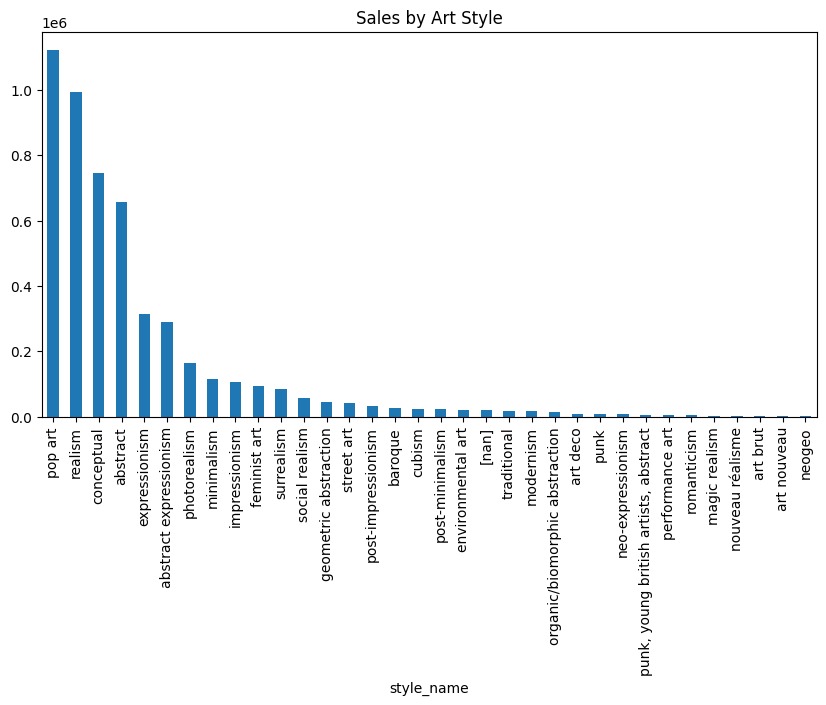

In [11]:
sales_by_style.plot(
    kind='bar',
    x='style_name',
    y='total_sales',
    figsize=(10,5),
    legend=False,
    title="Sales by Art Style"
)